## Simple Linaer Regression Completete end to end ML Project.

### Importing Libraires.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### Reading Data set.

In [2]:
df=pd.read_csv('height-weight.csv')

### Scatter Plot.

Text(0, 0.5, 'Height')

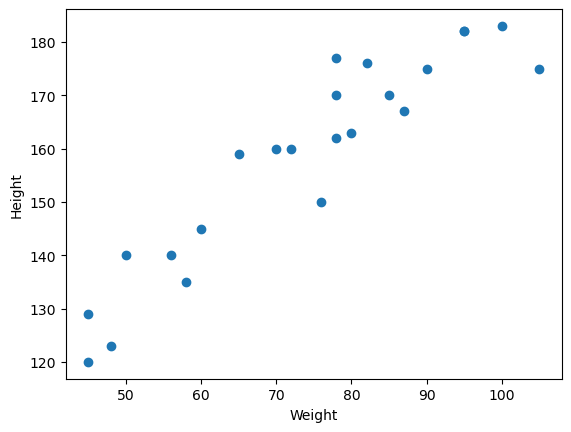

In [3]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

### Correlation

In [4]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


### Seaborn for visualization

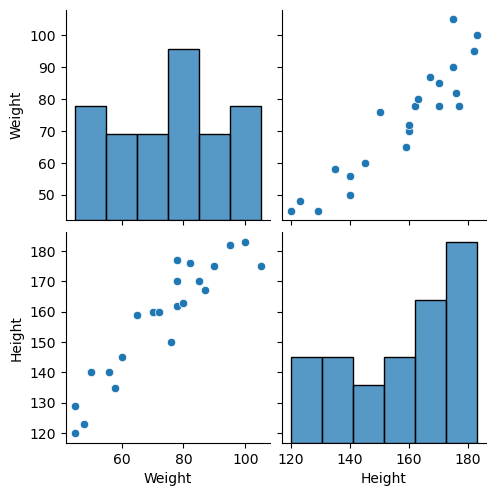

In [5]:
import seaborn as sns
sns.pairplot(df)

### Independent and dependent features

In [6]:
X=df[['Weight']] ### independent features should be data frame or 2 dimesnionalarray
y=df['Height'] ## this variiable can be in series or 1d array

In [7]:
X_series=df['Weight']
np.array(X_series).shape

(23,)

In [8]:
np.array(y).shape

(23,)

### Train Test Split


In [9]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20, random_state=42)

In [15]:
X_train.shape, X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

### Standardization

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [18]:
X_test=scaler.transform(X_test)

### Apply Simple Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
regression=LinearRegression()

In [27]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [17.03440872]
Intercept: 157.5


### plot Training data plot best fit line

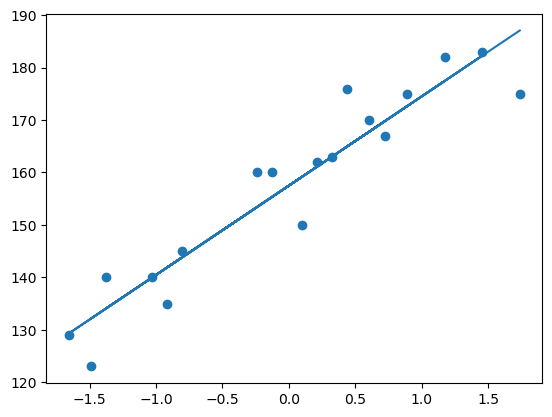

In [30]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

### prediction of test data
    1. predicted height output= intercept +coef_(Weights)
    2. y_pred_test =156.470 + 17.29(X_test)

### Prediction for test data

In [33]:
y_pred_test=regression.predict(X_test)

In [35]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

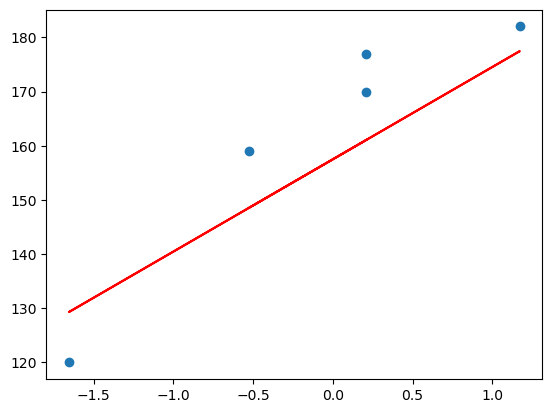

In [38]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regression.predict(X_test),"r")

### Performance Metrics

In [39]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [40]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


### R square
Formula

R^2 = 1 - SSR/SST

R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares

In [41]:
from sklearn.metrics import r2_score

In [42]:
score=r2_score(y_test,y_pred)
print(score)

0.776986986042344


### Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]

where:

R2: The R2 of the model n: The number of observations k: The number of predictor variables

In [43]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

## OLS Linear Regression

In [44]:
## New Datapoint

In [45]:
scaled_weight = scaler.transform([[80]])

C:\Users\Uzair khan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [46]:
scaled_weight

array([[0.32350772]])

In [49]:
regression.predict([scaled_weight[0]])

array([163.01076266])

In [50]:
print("The height for the weight 80 kg is ",regression.predict([scaled_weight[0]]))

The height for the weight 80 kg is  [163.01076266]


### Assumption

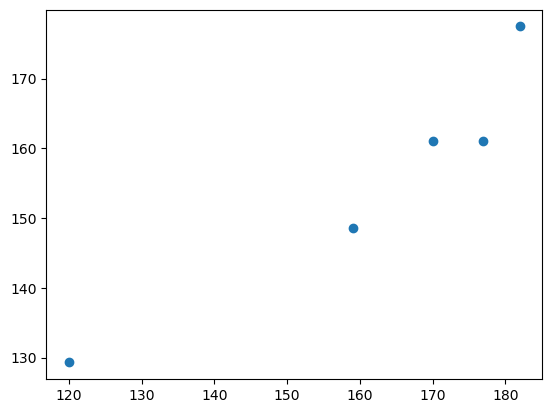

In [51]:
plt.scatter(y_test, y_pred_test)

In [53]:
residul = y_test-y_pred_test

In [54]:
residul

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

In [55]:
import seaborn as sns

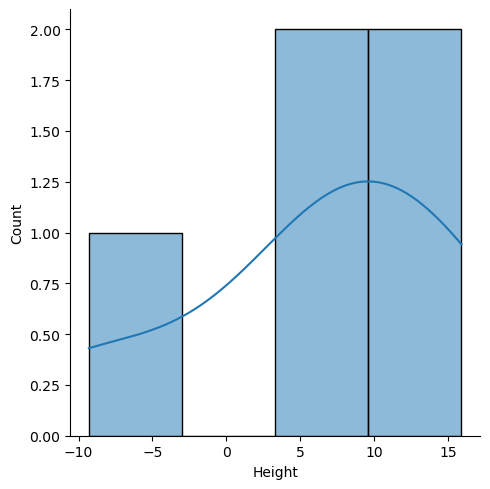

In [57]:
sns.displot(residul, kde=True)